In [2]:
"""ML"""
import torch
import torch.nn.functional as F
import numpy as np

"""Visualization"""
from matplotlib import pyplot as plt

"""Utils"""
# Add Base directory to Python path
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))
from Utils.paths import *
import Utils.plotting as plotting


torch.manual_seed(0)
np.random.seed(0)

%load_ext autoreload
%autoreload 2

torch.__version__, np.__version__

('2.5.1+cu118', '2.0.1')

dict_keys(['vehicle', 'person', 'bicycle', 'uav'])


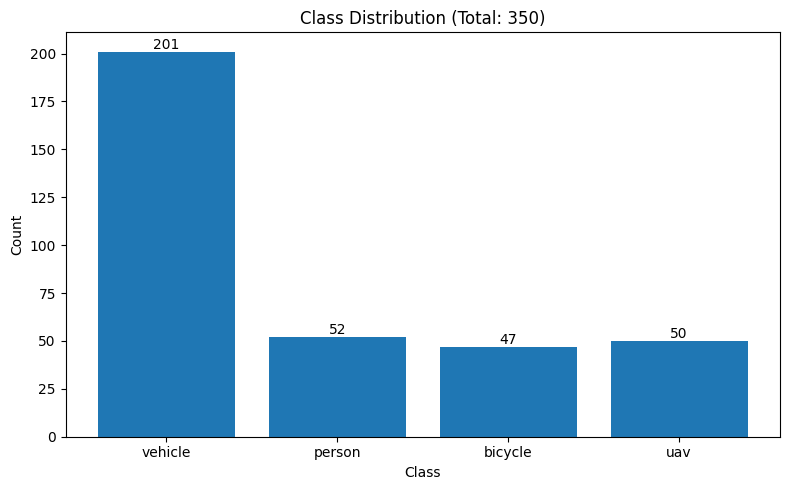

In [3]:
filename = PATHS['DATASET'] + "/moving_target_dataset.npy"
signatures = np.load(filename, allow_pickle=True)

class_names = []
class_counts = {}
signature_bin_size = []
for signature in signatures:
    if not any(signature['class_name'] in s for s in class_names):
        class_names.append(signature['class_name'])
    class_counts[signature['class_name']] = class_counts.get(signature['class_name'], 0) + 1
    signature_bin_size.append(signature['signature'].shape[0])

print(class_counts.keys())

# Extract keys and values
classes = list(class_counts.keys())
counts = list(class_counts.values())

plotting.plot_histogram_from_dict(class_counts, title=f"Class Distribution (Total: {sum(counts)})")

There is a huge imbalance in classes. 

Either 
* crop the `vehicle` class OR
* duplicate and augment the other three classes to match up with the vehicle class OR
* do a little bit of both


***

In [4]:
signatures[0].keys()

dict_keys(['signature', 'ts', 'range', 'azimuth', 'velocity', 'snr_db', 'x', 'y', 'z', 'class_name', 'radar_parameters', 'id'])

In [5]:
signatures[1]['signature'].shape[0], signatures[2]['signature'].shape[0], signatures[3]['signature'].shape[0]

(95, 104, 105)

Check if timestamps are sorted and unique

In [ ]:
all(np.all(np.diff(sig['ts']) >= 0) for sig in signatures)

True

In [23]:
for sig in signatures:
    # print(sig['class_name'], sig['signature'].shape)
    ts = sig['ts']
    is_sorted_unique = np.sum(np.sort(ts) == ts) == ts.shape[0] # Check if timestamps are sorted and unique
    if not is_sorted_unique:
        print(f"Warning: timestamps in signature {sig['class_name']} are not sorted or unique")

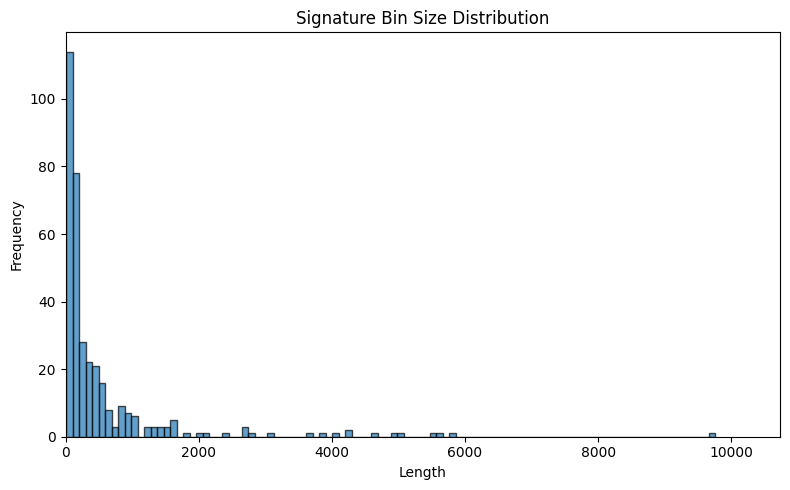

Mean: 535.41, Std: 1036.83, Min: 11, Max: 9757


In [6]:
plotting.plot_length_distribution(signature_bin_size, title="Signature Bin Size Distribution", bins=100)

print(f"Mean: {np.array(signature_bin_size).mean():.2f}, Std: {np.array(signature_bin_size).std():.2f}, Min: {np.array(signature_bin_size).min()}, Max: {np.array(signature_bin_size).max()}")

Theres a few above 2000 number of bins. Checking if its class focused...

Signatures with bin size greater than 9000:
person (9757, 1008)

Signatures with bin size between 2000 and 6000:
uav (3822, 1008)
uav (2381, 1008)
person (5065, 1008)
person (5537, 1008)
person (4278, 1008)
uav (4933, 1008)
uav (4651, 1008)
uav (2680, 1008)
uav (3702, 1008)
uav (4078, 1008)
person (5595, 1008)
person (5852, 1008)
person (4295, 1008)
person (2708, 1008)
bicycle (3115, 1008)
person (2127, 1008)
person (2757, 1008)
person (2660, 1008)


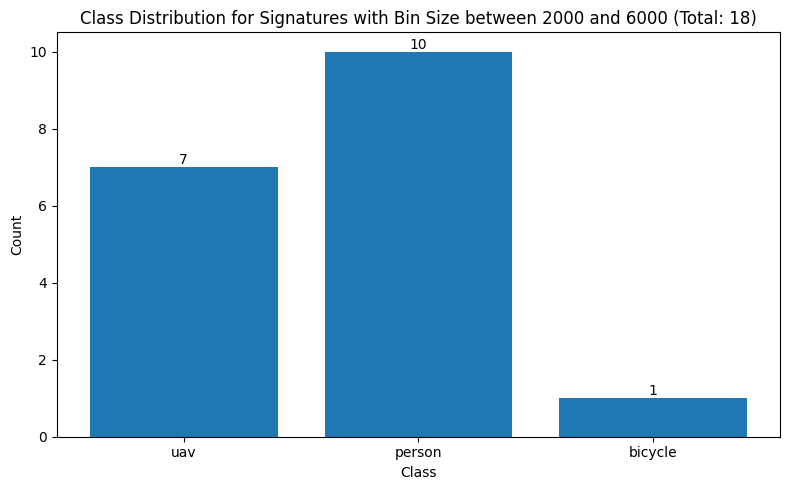

In [7]:
# print(f"Max signature bin size: {max(signature_bin_size)}")
print("Signatures with bin size greater than 9000:")
for signature in signatures:
    if signature['signature'].shape[0] > 9000:
        print(signature['class_name'], signature['signature'].shape)

# printing signature bin size between 2000 and 6000
# tracking signature bin size between 2000 and 6000 with a dictionary
signature_bin_size_dict = {}


# print(signature_bin_size_dict)
print("\nSignatures with bin size between 2000 and 6000:")
for signature in signatures:
    if 2000 < signature['signature'].shape[0] < 6000:
        print(signature['class_name'], signature['signature'].shape)
        signature_bin_size_dict[signature['class_name']] = signature_bin_size_dict.get(signature['class_name'], 0) + 1
plotting.plot_histogram_from_dict(signature_bin_size_dict, title=f"Class Distribution for Signatures with Bin Size between 2000 and 6000 (Total: {sum(signature_bin_size_dict.values())})")

<a id='ds_desc_id'></a>
***

**signature: (R, 1008) complex**
<!-- ```text -->
where R is number of range bins for that object (variable)

1008 = pulses (slow-time axis)

values are complex I + jQ


Vertical axis: distance slices through the object

Horizontal axis: temporal evolution over pulses

Values: coherent electromagnetic return

#### Range Bin Variance
This will be dealt with by padding the bins with zeros.

#### Channels - 3 options
1. **Magnitude Only**: 1 channel -> **|I + _j_ Q|**
2. **Two channels for I/Q**: 2 channels -> Slightly heavier but more expressive

For the purposes of this hackathon, We'll go with the first option since implementing 3D CNN's will be time consuming

After showing a few samples lies the [cleanup pipline](#preprocessing_pipeline_v1_id)

***

### Samples of plots of the microdoppler shift per class

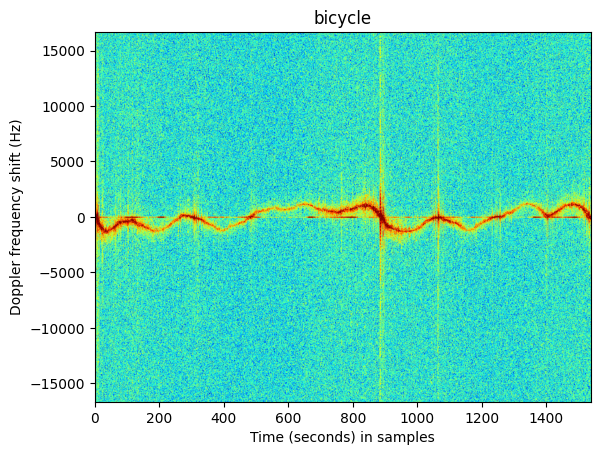

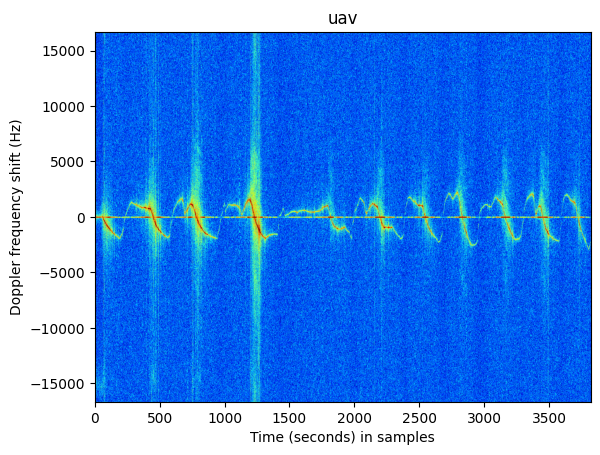

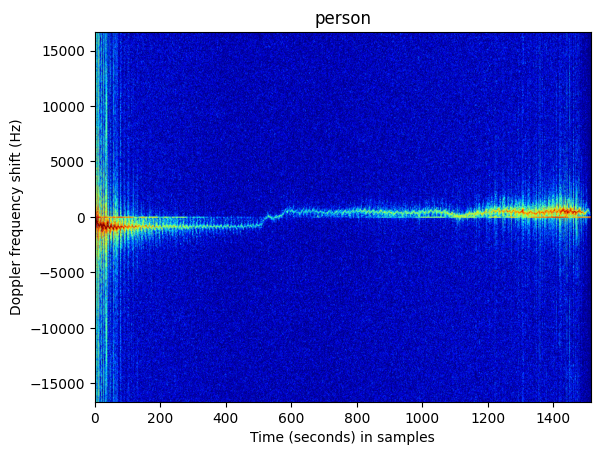

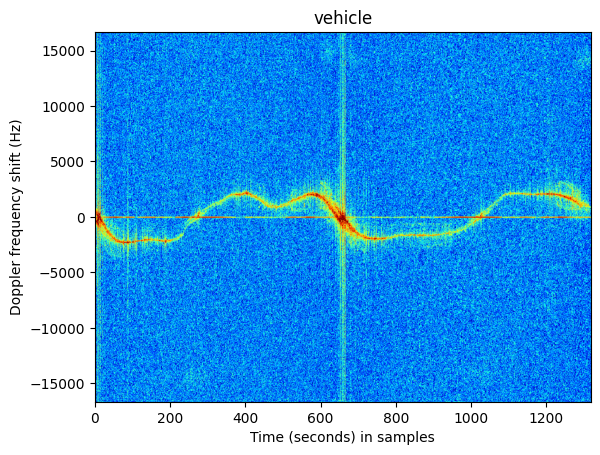

In [8]:
is_shown = {}
for class_name in class_names:
    is_shown[class_name] = False
    
for signature in signatures:
  if (len(signature['snr_db']) > 500) or (signature['class_name']=="uav" and len(signature['snr_db']) > 100):
      if(not is_shown[signature['class_name']]):
          is_shown[signature['class_name']] = True
          arr = signature['signature']
          arr = 20 * np.log10(np.abs(arr)).transpose()
          prf = signature['radar_parameters']['prf']
          plt.imshow(arr, cmap='jet', aspect='auto', vmax=np.max(arr) - 20, vmin=np.max(arr) - 70,
                        extent=[0, arr.shape[1], -int(prf/2), int(prf / 2)])
          plt.title(signature['class_name'])
          plt.autoscale()
          # plt.colorbar(axdata)
          plt.xlabel('Time (seconds) in samples')
          plt.ylabel('Doppler frequency shift (Hz)')
          plt.show()

### Magnitude (or real/imag) of the complex signature vs. time — without Doppler axis

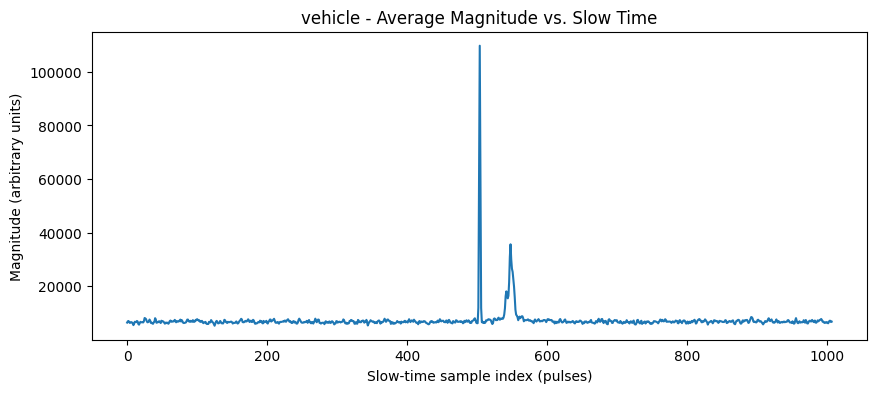

In [9]:
# Assuming signature['signature'] is complex-valued (most likely)
arr_complex = signature['signature']          # shape: (Doppler bins, time) or similar

# Option A: magnitude over time (collapse Doppler dimension)
magnitude_over_time = np.mean(np.abs(arr_complex), axis=0)   # or np.max, or select center bin

plt.figure(figsize=(10,4))
plt.plot(magnitude_over_time)
plt.title(f"{signature['class_name']} - Average Magnitude vs. Slow Time")
plt.xlabel("Slow-time sample index (pulses)")
plt.ylabel("Magnitude (arbitrary units)")
# plt.grid(True)
plt.show()

### Plot of real and imaginary parts separately

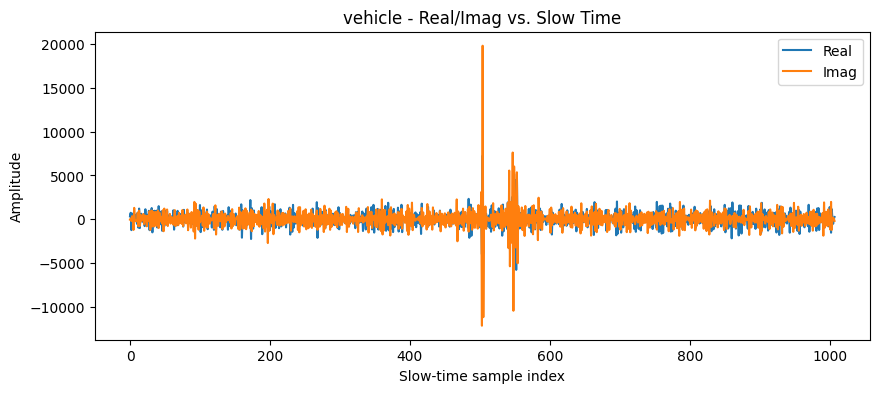

In [10]:
real_part = np.mean(np.real(arr_complex), axis=0)
imag_part = np.mean(np.imag(arr_complex), axis=0)

plt.figure(figsize=(10,4))
plt.plot(real_part, label='Real')
plt.plot(imag_part, label='Imag')
plt.title(f"{signature['class_name']} - Real/Imag vs. Slow Time")
plt.xlabel("Slow-time sample index")
plt.ylabel("Amplitude")
plt.legend()
# plt.grid(True)
plt.show()

### Plot of instantaneous phase or unwrapped phase

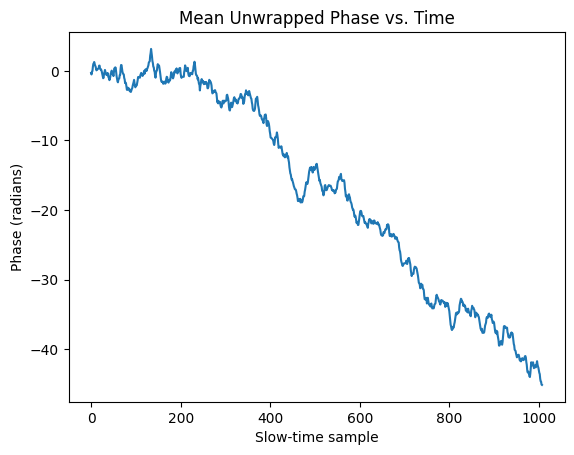

In [11]:
phase = np.unwrap(np.angle(arr_complex), axis=1)   # unwrap along time
mean_phase = np.mean(phase, axis=0)                 # or select specific Doppler bin

plt.plot(mean_phase)
plt.title("Mean Unwrapped Phase vs. Time")
plt.xlabel("Slow-time sample")
plt.ylabel("Phase (radians)")
plt.show()

### Train/test/split given in the dataset collab notebook

In [12]:


from sklearn.model_selection import train_test_split
from sklearn import preprocessing

all_indices = list(range(len(signatures)))
train_indices, test_indices = train_test_split(all_indices, test_size=0.2, random_state=42)

le = preprocessing.LabelEncoder()
le.fit_transform(class_names)

# for ind in train_indices:
train_signatures = [signatures[i] for i in train_indices]
test_signatures = [signatures[i] for i in test_indices]

#Count the Number of samples:
n_samples_train = 0
n_samples_test = 0
for signature in train_signatures:
    n_samples_train += len(signature['ts'])

for signature in test_signatures:
    n_samples_test += len(signature['ts'])


print("Train dataset size: " +str(n_samples_train))
print("Test dataset size: " +str(n_samples_test))



Train dataset size: 151455
Test dataset size: 35937


<a id='preprocessing_pipeline_v1_id'></a>

***
### Pipeline: Cleanup V1
A brief overview of the cleanup steps done below can be found [here](#ds_desc_id).

The main steps are:
1. FFT
2. taking the magnitude as decided in a few cells [above](#channels---3-options)
3. Log
4. Pad 

In [13]:
# =========================
# CONFIGURATION
# =========================
R_FIXED = 64
D_FIXED = 256


def preprocess_signature(signature_complex):
    """
    Converts raw radar signature (R x 1008 complex) into
    fixed-size CNN tensor (1 x 64 x 256).

    Parameters:
        signature_complex (np.ndarray): shape (R, 1008), dtype=complex64

    Returns:
        torch.Tensor: shape (1, 64, 256)
    """

    # 1. Doppler FFT (along pulses)
    doppler = np.fft.fft(signature_complex, axis=1)

    # 2. Shift zero Doppler to center
    doppler = np.fft.fftshift(doppler, axes=1)

    # 3. Magnitude
    magnitude = np.abs(doppler)

    # 4. Log scaling
    magnitude = np.log1p(magnitude)

    # 5. Convert to torch
    tensor = torch.tensor(magnitude, dtype=torch.float32)

    R_current, D_current = tensor.shape

    # 6. Fix Range dimension
    if R_current < R_FIXED:
        pad_amount = R_FIXED - R_current
        tensor = F.pad(tensor, (0, 0, 0, pad_amount))  # pad bottom
    else:
        tensor = tensor[:R_FIXED, :]

    # 7. Fix Doppler dimension
    center = D_current // 2
    half = D_FIXED // 2
    start = center - half
    end = center + half

    tensor = tensor[:, start:end]

    # 8. Add channel dimension
    tensor = tensor.unsqueeze(0)  # (1, 64, 256)

    return tensor

<a id='improving_pipeline_id'></a>

#### Future Potential Improvements to the [pipeline](#ds_desc_id)
- Mean-variance normalization

- SNR masking

- Windowing before FFT

- Velocity-axis normalization

In [14]:
sample = signatures[0]['signature']  # complex array
processed = preprocess_signature(sample)

print(processed.shape)

torch.Size([1, 64, 256])


1   -> magnitude / channel

64  -> range bins

256 -> doppler bins

***

<a id='energy_dist_id'></a>

### Energy Distributions

Checking if samples are distributed sparsely or compact in terms of the energy of the signal (in arbitrary units). 

This will help to check whether interpolation or energy focused trimming will help for the dataset.

In [15]:
# Checks energy signature of one scan
def analyze_large_signature(signature_complex, energy_threshold=0.95, verbose=False):
    """
    Analyze energy distribution of large radar signature.

    Parameters:
        signature_complex (np.ndarray): shape (R, 1008), complex
        energy_threshold (float): cumulative energy threshold (e.g., 0.95)

    Returns:
        dict with statistics
    """

    R, T = signature_complex.shape

    if verbose:
        print(f"\nAnalyzing signature with shape: ({R}, {T})")


    # 1. Doppler FFT

    doppler = np.fft.fft(signature_complex, axis=1)
    doppler = np.fft.fftshift(doppler, axes=1)

    magnitude = np.abs(doppler)


    # 2. Row-wise energy

    row_energy = np.sum(magnitude**2, axis=1)

    total_energy = np.sum(row_energy)

    # Normalize
    row_energy_norm = row_energy / total_energy


    # 3. Cumulative energy

    cumulative_energy = np.cumsum(row_energy_norm)

    # Find rows needed to reach threshold
    rows_needed = np.searchsorted(cumulative_energy, energy_threshold)

    percent_rows_needed = rows_needed / R

    if verbose:
        print(f"Total rows: {R}")
        print(f"Rows needed for {energy_threshold*100:.1f}% energy: {rows_needed}")
        print(f"Fraction of rows needed: {percent_rows_needed:.4f}")


    # 4. Sparsity analysis

    near_zero_rows = np.sum(row_energy_norm < 1e-6)
    if verbose:
        print(f"Rows with near-zero energy (<1e-6): {near_zero_rows}")
        print(f"Fraction near-zero: {near_zero_rows / R:.4f}")


    # 5. Plot energy distribution
    if verbose:
        plt.figure()
        plt.plot(row_energy_norm)
        plt.title("Row-wise Normalized Energy")
        plt.xlabel("Range Bin Index")
        plt.ylabel("Normalized Energy")
        plt.show()


        # 6. Plot cumulative energy

        plt.figure()
        plt.plot(cumulative_energy)
        plt.axhline(y=energy_threshold, linestyle='--')
        plt.title("Cumulative Energy Distribution (Normalized)")
        plt.xlabel("Range Bin Index")
        plt.ylabel("Cumulative Energy")
        plt.show()

    return {
        "total_rows": R,
        "rows_for_threshold": rows_needed,
        "fraction_rows_for_threshold": percent_rows_needed,
        "near_zero_rows": near_zero_rows
    }

In [16]:
energy_threshold_rows_frac = []
energy_threshold_rows_count = []
threshold = 0.95
for sig in signatures:
    R = sig['signature'].shape[0]
    stats = analyze_large_signature(sig['signature'], energy_threshold=threshold, verbose=False)
    energy_threshold_rows_frac.append(stats["fraction_rows_for_threshold"])
    energy_threshold_rows_count.append(stats["rows_for_threshold"])

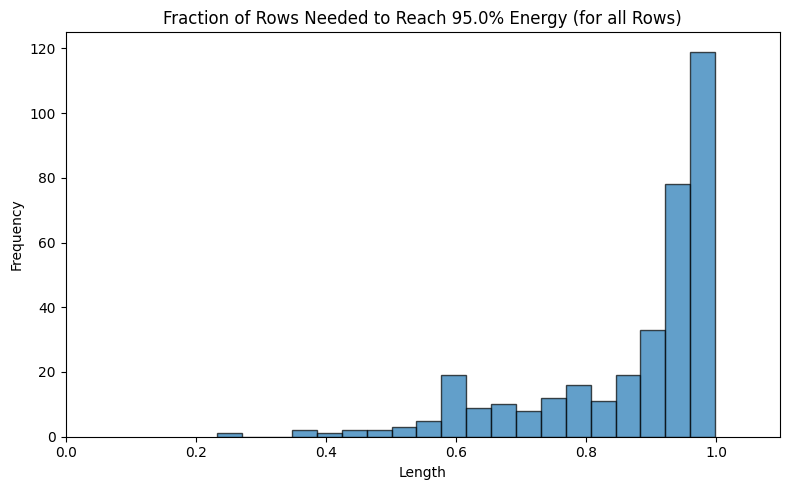

Mean fraction of rows needed: 0.8701
Std: 0.1457

Min: 0.2333
Max: 0.9986


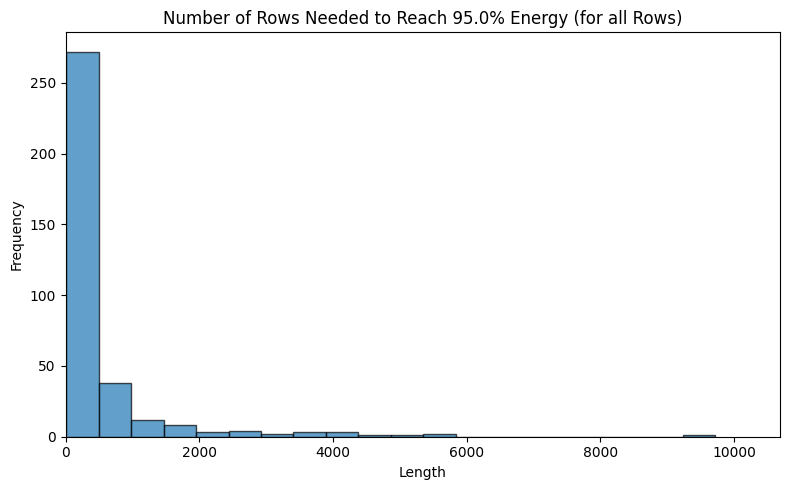

Mean number of rows needed: 490.3800
Std: 989.0190

Min: 10.0000
Max: 9715.0000


In [17]:
plotting.plot_length_distribution(energy_threshold_rows_frac, bins=20, title=f"Fraction of Rows Needed to Reach {threshold*100:.1f}% Energy (for all Rows)")
print(f"Mean fraction of rows needed: {np.mean(energy_threshold_rows_frac):.4f}\nStd: {np.std(energy_threshold_rows_frac):.4f}\n\nMin: {np.min(energy_threshold_rows_frac):.4f}\nMax: {np.max(energy_threshold_rows_frac):.4f}")

plotting.plot_length_distribution(energy_threshold_rows_count, bins=20, title=f"Number of Rows Needed to Reach {threshold*100:.1f}% Energy (for all Rows)")
print(f"Mean number of rows needed: {np.mean(energy_threshold_rows_count):.4f}\nStd: {np.std(energy_threshold_rows_count):.4f}\n\nMin: {np.min(energy_threshold_rows_count):.4f}\nMax: {np.max(energy_threshold_rows_count):.4f}")

Compressing to 128 might be a little too aggressive. If the range bins are evenly spaced, start off with compression to 256 
***

In [18]:
def analyze_range_spacing(range_array, tolerance_ratio=0.01, verbose=False):
    """
    Analyze whether range bins are evenly spaced in meters.

    Parameters:
        range_array (np.ndarray): shape (R,), physical range values in meters
        tolerance_ratio (float): allowed relative std deviation threshold

    Returns:
        dict with statistics
    """

    diffs = np.diff(range_array)

    mean_spacing = np.mean(diffs)
    std_spacing = np.std(diffs)
    rel_std = std_spacing / abs(mean_spacing)

    if verbose:
        print("\nRange Spacing Analysis")
        print("-----------------------")
        print(f"Number of bins: {len(range_array)}")
        print(f"Mean spacing (meters): {mean_spacing:.6f}")
        print(f"Std spacing: {std_spacing:.6f}")
        print(f"Relative std: {rel_std:.6f}")

    evenly_spaced = rel_std < tolerance_ratio

    if verbose:
        print(f"Evenly spaced (within {tolerance_ratio*100:.1f}% tolerance)? {evenly_spaced}")

    return {
        "mean_spacing": mean_spacing,
        "std_spacing": std_spacing,
        "relative_std": rel_std,
        "evenly_spaced": evenly_spaced,
        "extreme_deltas": np.sum(np.abs(diffs - mean_spacing) > 3 * std_spacing) # count of bins with spacing far from mean
    }
def plot_range_vs_index(range_array, verbose=False):
    """
    Plot physical range values vs row index.
    """

    indices = np.arange(len(range_array))

    plt.figure()
    plt.plot(indices, range_array)
    plt.title("Physical Range vs Row Index")
    plt.xlabel("Row Index")
    plt.ylabel("Range (meters)")
    plt.show()

    # Also plot spacing
    diffs = np.diff(range_array)

    plt.figure()
    plt.plot(diffs)
    plt.title("Range Bin Spacing Between Consecutive Rows")
    plt.xlabel("Row Index")
    plt.ylabel("Delta Range (meters)")
    plt.show()

In [19]:
def dataset_range_spacing_stats(signatures, tolerance_ratio=0.05):
    """
    Compute range spacing statistics across entire dataset.

    tolerance_ratio:
        Threshold below which we consider spacing approximately uniform.
        0.05 = 5% relative variation
    """

    rel_stds = []
    mean_spacings = []
    num_bins = []

    extreme_jump_counts = []

    for sig in signatures:
        range_vals = sig['range']
        if len(range_vals) < 2:
            continue

        diffs = np.diff(range_vals)

        mean_spacing = np.mean(diffs)
        std_spacing = np.std(diffs)

        if abs(mean_spacing) < 1e-9:
            continue

        rel_std = std_spacing / abs(mean_spacing)

        # Count extreme jumps
        extreme_jumps = np.sum(np.abs(diffs - mean_spacing) > 3 * std_spacing)

        rel_stds.append(rel_std)
        mean_spacings.append(mean_spacing)
        num_bins.append(len(range_vals))
        extreme_jump_counts.append(extreme_jumps)

    rel_stds = np.array(rel_stds)
    

    print("\n===== Dataset Range Spacing Statistics =====")
    print(f"Total samples analyzed: {len(rel_stds)}")
    print(f"Mean relative std: {rel_stds.mean():.4f}")
    print(f"Std of relative std: {rel_stds.std():.4f}")
    print(f"Min relative std: {rel_stds.min():.4f}")
    print(f"Max relative std: {rel_stds.max():.4f}")

    approx_uniform = np.sum(rel_stds < tolerance_ratio)
    print(f"Samples < {tolerance_ratio*100:.1f}% variation: "
          f"{approx_uniform} ({approx_uniform/len(rel_stds)*100:.2f}%)")

    # Histogram
    # Removing the >70,000 outlier for better visualization
    rel_stds_filtered = rel_stds[rel_stds < 70000]
    plt.figure()
    plt.hist(rel_stds_filtered, bins=30)
    plt.title("Distribution of Relative Std of Range Spacing")
    plt.xlabel("Relative Std")
    plt.ylabel("Count")
    plt.show()

    return rel_stds


===== Dataset Range Spacing Statistics =====
Total samples analyzed: 350
Mean relative std: 279.6386
Std of relative std: 4044.6204
Min relative std: 0.3551
Max relative std: 75740.6527
Samples < 5.0% variation: 0 (0.00%)


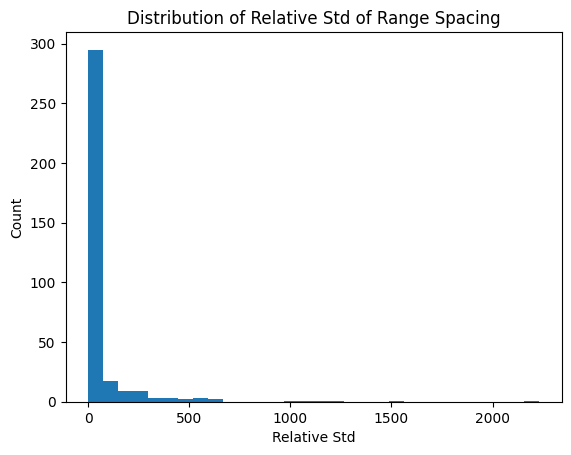

In [21]:
rel_stds = dataset_range_spacing_stats(signatures, tolerance_ratio=0.05)

### Main Takeaway
**The pulses are over a good amount of time and range. Will have to use a energy filter based sliding window with a robust selection rule**

The preprocessing pipeline will revolve around this. 